# 👨‍💼 Employee Attrition Prediction — HR Analytics

## 🎯 Objective
Predict employee attrition using machine learning and identify the key factors influencing employee turnover.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style('whitegrid')

In [2]:
df=pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
print(df.shape)
df.info()

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

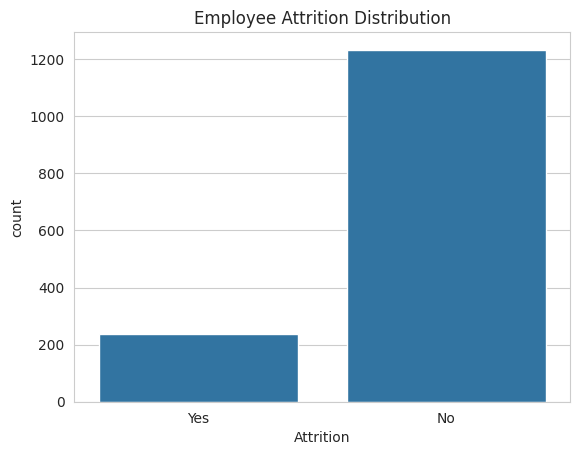

In [6]:
sns.countplot(x='Attrition',data=df)
plt.title('Employee Attrition Distribution')
plt.show()

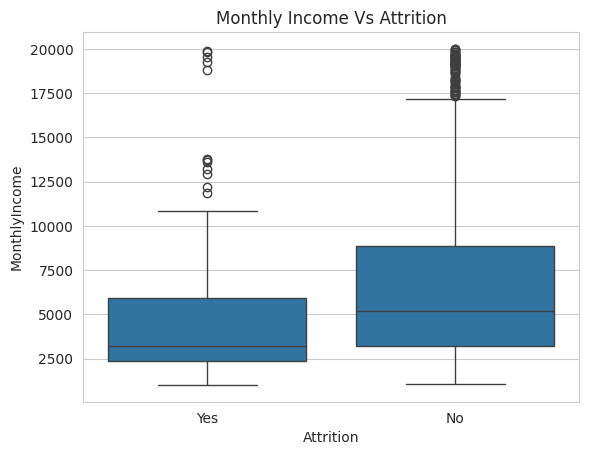

In [7]:
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df)
plt.title("Monthly Income Vs Attrition")
plt.show()

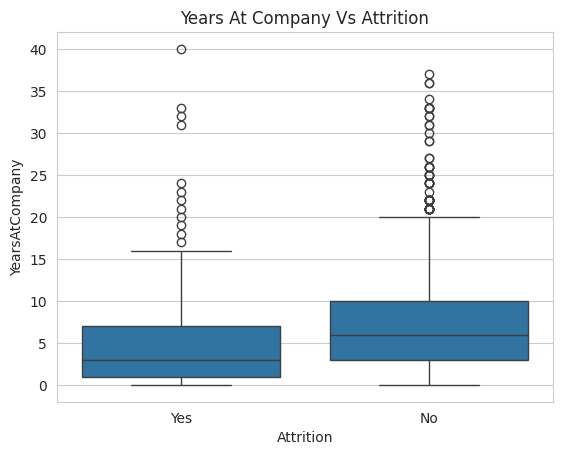

In [8]:
sns.boxplot(x='Attrition',y='YearsAtCompany',data=df)
plt.title('Years At Company Vs Attrition')
plt.show()

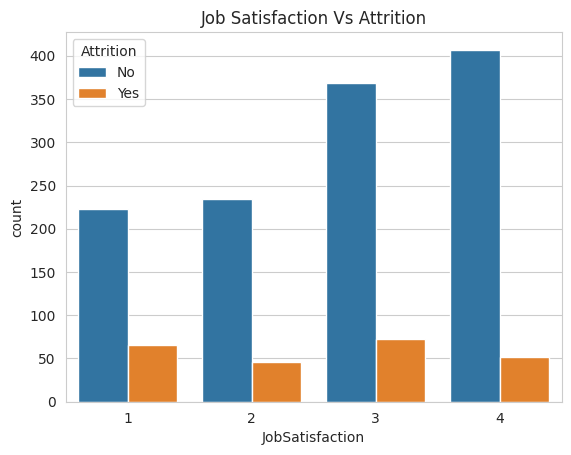

In [9]:
sns.countplot(x='JobSatisfaction',hue='Attrition',data=df)
plt.title('Job Satisfaction Vs Attrition')
plt.show()

- Employees with lower income show higher attrition
- Lower job satisfaction increases churn risk
- Early-career employees are more likely to leave

## ⚙️ Data Cleaning + Preprocessing
Preparing the dataset for machine learning modeling.

In [10]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [11]:
drop_cols=[
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]
df=df.drop(drop_cols,axis=1)

In [12]:
df['Attrition']=df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [13]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

cat_cols=df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col]=le.fit_transform(df[col])

In [14]:
x=df.drop('Attrition',axis=1)
y=df['Attrition']

In [15]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [17]:
print(x_train.shape)
print(x_test.shape)

(1176, 30)
(294, 30)


- Categorical features were encoded for ML compatibility
- Constant and irrelevant columns were removed
- Feature scaling improves model stability and performance

## 🤖 Baseline Models
Training baseline models to predict employee attrition.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,roc_auc_score

log_model=LogisticRegression(random_state=42)
log_model.fit(x_train,y_train)

log_preds=log_model.predict(x_test)
log_probs=log_model.predict_proba(x_test)[:,1]

In [19]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, log_probs))
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.8741496598639455
ROC-AUC Score: 0.8056680161943319
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



In [20]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train,y_train)

rf_preds=rf.predict(x_test)
rf_probs=rf.predict_proba(x_test)[:,1]

In [21]:
print('Random Forest Accuracy:',accuracy_score(y_test,rf_preds))
print('ROC-AUC Score:',roc_auc_score(y_test,rf_probs))
print(classification_report(y_test,rf_preds))

Random Forest Accuracy: 0.8367346938775511
ROC-AUC Score: 0.7935222672064777
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.46      0.13      0.20        47

    accuracy                           0.84       294
   macro avg       0.66      0.55      0.55       294
weighted avg       0.79      0.84      0.80       294



In [22]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs)
    ]
})
results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.874150,0.805668
1,Random Forest,0.836735,0.793522


## 📈 Model Comparison

Logistic Regression outperformed Random Forest in both Accuracy and ROC-AUC.

This suggests that employee attrition patterns are captured effectively by a simpler and more interpretable model.

## 🚀 Advanced Model — XGBoost + Hyperparameter Tuning
Using XGBoost to improve prediction performance and identify stronger attrition patterns.

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score,classification_report

In [24]:
xgb=XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
xgb_preds=xgb.predict(x_test)
xgb_probs=xgb.predict_proba(x_test)[:,1]

In [26]:
print('XGBoost ROC-AUC:',roc_auc_score(y_test,xgb_probs))
print(classification_report(y_test,xgb_preds))

XGBoost ROC-AUC: 0.8055818761305883
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.73      0.23      0.35        47

    accuracy                           0.86       294
   macro avg       0.80      0.61      0.64       294
weighted avg       0.85      0.86      0.83       294



In [27]:
from sklearn.model_selection import GridSearchCV

param_grid={
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[100,200]
}

grid=GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(x_train,y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='roc_auc')

In [28]:
print('Best Parameters:',grid.best_params_)
print('Best ROC-AUC:',grid.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}
Best ROC-AUC: 0.7949145563958444


In [29]:
best_xgb=grid.best_estimator_

best_preds=best_xgb.predict(x_test)
best_probs=best_xgb.predict_proba(x_test)[:,1]

print('Final ROC-AUC:',roc_auc_score(y_test,best_probs))
print(classification_report(y_test,best_preds))

Final ROC-AUC: 0.7754328538203118
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.72      0.28      0.40        47

    accuracy                           0.87       294
   macro avg       0.80      0.63      0.66       294
weighted avg       0.85      0.87      0.84       294



- XGBoost captures complex relationships better than baseline models
- Hyperparameter tuning improves model generalization
- ROC-AUC helps evaluate ranking quality beyond simple accuracy

## 🧠 Feature Importance + Business Insights
Understanding the major drivers of employee attrition using model interpretation.

In [30]:
import matplotlib.pyplot as plt
import numpy as np

importances=best_xgb.feature_importances_
indices=np.argsort(importances)[-15:]

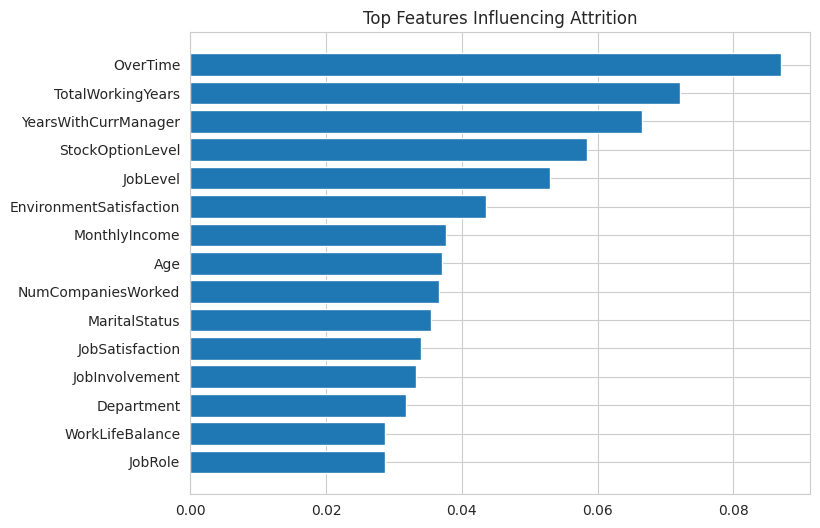

In [31]:
plt.figure(figsize=(8,6))

plt.barh(
    range(len(indices)),
    importances[indices]
)

plt.yticks(
    range(len(indices)),
    x.columns[indices]
)
plt.title('Top Features Influencing Attrition')
plt.show()

<Figure size 1000x600 with 0 Axes>

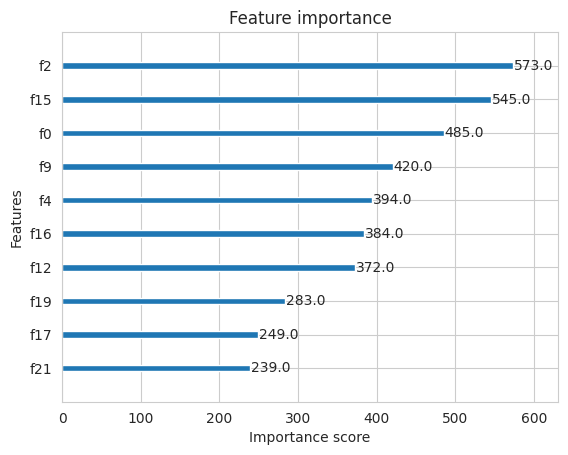

In [32]:
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(best_xgb,max_num_features=10)
plt.show()

In [33]:
important_features=pd.DataFrame({
    "Feature":x.columns,
    "Importance":best_xgb.feature_importances_
}).sort_values(by='Importance',ascending=False)

important_features.head(10)

,Feature,Importance
18,OverTime,0.086935
23,TotalWorkingYears,0.072194
29,YearsWithCurrManager,0.066555
22,StockOptionLevel,0.058462
11,JobLevel,0.053006
7,EnvironmentSatisfaction,0.043525
15,MonthlyIncome,0.037696
0,Age,0.037060
17,NumCompaniesWorked,0.036655
14,MaritalStatus,0.035449


## 💼 Business Insights

Key drivers of employee attrition include:

- Monthly Income  
- Years at Company  
- Job Satisfaction  
- Overtime  
- Distance From Home  
- Work-Life Balance  

### HR Recommendations

- Improve employee engagement programs  
- Focus on early-career employee retention  
- Reduce overtime pressure  
- Improve compensation strategies  
- Strengthen manager feedback systems

In [34]:
final_results=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC":[
        roc_auc_score(y_test,log_probs),
        roc_auc_score(y_test,rf_probs),
        roc_auc_score(y_test,best_probs)
    ]
})
final_results

,Model,ROC-AUC
0,Logistic Regression,0.805668
1,Random Forest,0.793522
2,XGBoost,0.775433


## 📌 Final Model Comparison

Logistic Regression achieved the highest ROC-AUC score (0.8057), outperforming both Random Forest and XGBoost.

This indicates that employee attrition patterns are captured effectively using a simpler and more interpretable model.

In HR Analytics, interpretability is highly valuable because decision-makers need clear explanations for employee turnover predictions.

Although XGBoost is a powerful model, Logistic Regression proved to be the best fit for this problem due to better generalization and easier interpretability for HR decision-making.